# EDA - Practica

## 0. Importar las librerias necesarias

In [285]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Leer el conjunto de datos (Pandas)

In [286]:
datos = pd.read_csv("dataset_original.csv")
datos.head()

,Transaction_ID,Customer_Name,Age,Gender,Income,Join_Date,Purchase_Amount,Is_Subscribed,City
0,TRX-2824,Alice M.,999.0,F,NaN,09/09/2021,279.912294,True,los angeles
1,TRX-1409,Alice M.,22.0,m,NaN,2021-06-07,158.384057,No,NaN
2,TRX-5506,Frank_Wright,-4.0,NaN,127874,10/15/2022,256.260841,True,Chicago
3,TRX-5012,Grace!!,-4.0,f,NaN,02/17/2022,471.387424,False,Chicago
4,TRX-4657,Alice M.,999.0,Male,Unknown,30-09-2023,332.779108,N,New York


## 2. Inspección inicial del conjunto de datos

In [287]:
## Metadatos del dataset
print(datos.shape)  ##(filas, columnas)
print(datos.dtypes) ## Tipos de datos de cada columna
print("-------------- Metadatos generales del dataset --------------")
print(datos.info())
print("-------------- Estadisticas descrptivas --------------")
print(datos.describe())


(155, 9)
Transaction_ID         str
Customer_Name          str
Age                float64
Gender                 str
Income                 str
Join_Date              str
Purchase_Amount    float64
Is_Subscribed          str
City                   str
dtype: object
-------------- Metadatos generales del dataset --------------
<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction_ID   155 non-null    str    
 1   Customer_Name    155 non-null    str    
 2   Age              129 non-null    float64
 3   Gender           134 non-null    str    
 4   Income           89 non-null     str    
 5   Join_Date        124 non-null    str    
 6   Purchase_Amount  144 non-null    float64
 7   Is_Subscribed    155 non-null    str    
 8   City             139 non-null    str    
dtypes: float64(2), str(7)
memory usage: 17.0 KB
None
-------------- Esta

## 3. Identificar y solucionar problematicas generales de los datos

In [288]:
## Tipos de datos
print(datos.dtypes)

Transaction_ID         str
Customer_Name          str
Age                float64
Gender                 str
Income                 str
Join_Date              str
Purchase_Amount    float64
Is_Subscribed          str
City                   str
dtype: object


In [289]:
## Trnasaction ID
datos['TipoTransaccion'] = datos['Transaction_ID'].str.split("-").str[0]
datos['NumeroTransaccion'] = datos['Transaction_ID'].str.split("-").str[1]

In [290]:
## Income
datos['Income'].value_counts()

## Arreglar los caracteres extraños en los numeros 
datos['Income'] = datos['Income'].str.replace('$', '')  ## Quitamos el signo de pesos
datos['Income'] = datos['Income'].str.replace(',', '')  ## Quitamos la coma

### Arreglemos los Unknown, N/A y cualquier otro valor que no sea un número
datos['Income Limpio'] = pd.to_numeric(datos['Income'], errors='coerce')  ## Esto convertirá los valores que no sean números a NaN

#datos[['Income Limpio', 'Income']]

In [291]:
datos['Join_Date'].value_counts()

Join_Date
2023/15/01    25
10/26/2020     2
06/16/2020     2
06/08/2021     2
09/09/2021     1
              ..
14-05-2020     1
2020-05-31     1
09/11/2020     1
27-11-2020     1
06/10/2020     1
Name: count, Length: 97, dtype: int64

In [292]:
def reorganizar_fecha(fecha):
    
    fecha = str(fecha)
    if fecha == "nan":
        return fecha
    valor1, valor2, valor3 = fecha.split("/")
    
    if int(valor3)>1990:
        if int(valor1)>12:
            return f"{valor2}/{valor1}/{valor3}"  ## Si el primer valor es mayor a 12, entonces es el mes, por lo que la fecha está en formato DD/MM/YYYY
        if int(valor2)>12:
            return f"{valor1}/{valor2}/{valor3}"  ## Si el tercer valor es mayor a 1900, entonces es el año, por lo que la fecha está en formato MM/DD/YYYY
        else:
            return f"{valor2}/{valor1}/{valor3}"  ## Si ninguno de los valores es mayor a 12, entonces la fecha está en formato DD/MM/YYYY

    if int(valor1)>1900:
        if int(valor2)>12:
            return f"{valor2}/{valor3}/{valor1}"  ## Si el segundo valor es mayor a 12, entonces es el mes, por lo que la fecha está en formato YYYY/DD/MM
        if int(valor3)>12:
            return f"{valor3}/{valor2}/{valor1}"  ## Si el tercer valor es mayor a 12, entonces es el mes, por lo que la fecha está en formato YYYY/MM/DD
        else:
            return f"{valor2}/{valor3}/{valor1}"  ## Si ninguno de los valores es mayor a 12, entonces la fecha está en formato DD/MM/YYYY
    if int(valor1)>12:
        if int(valor2)>1900:
            return f"{valor3}/{valor1}/{valor2}"  ## Si el primer valor es mayor a 12, entonces es el mes, por lo que la fecha está en formato DD/MM/YYYY
        if int(valor3)>1900:
            return f"{valor2}/{valor1}/{valor3}"  ## Si el tercer valor es mayor a 1900, entonces es el año, por lo que la fecha está en formato MM/DD/YYYY


In [293]:
reorganizar_fecha("10/15/2022")  

'10/15/2022'

In [294]:
## Join Date
datos['Join_Date'].value_counts()

datos['Join_Date'] = datos['Join_Date'].str.replace('-', '/')  ## Reemplazamos los guiones por barras para que pandas pueda reconocer la fecha correctamente

## aplicar funcion reorganizar_fecha a la columna Join_Date
datos['Join Date Limpio'] = datos['Join_Date'].apply(reorganizar_fecha)

datos["Join Date Limpio"] = pd.to_datetime(datos['Join Date Limpio'], errors='coerce')  ## Esto convertirá los valores que no sean fechas a NaT

datos[['Join Date Limpio', 'Join_Date']]

,Join Date Limpio,Join_Date
0,2021-09-09,09/09/2021
1,2021-06-07,2021/06/07
2,2022-10-15,10/15/2022
3,2022-02-17,02/17/2022
4,2023-09-30,30/09/2023
...,...,...
150,2020-06-16,06/16/2020
151,2020-10-26,10/26/2020
152,NaT,NaN
153,2021-08-06,06/08/2021


In [295]:
## Valores nulos

print(datos.isnull().sum())  ## Esto nos dará el número de valores nulos por columna

## Arreglar los nulos en columnas categoricas
### Usar un valor "Desconocido" como referencia par el valor faltante

datos["Gender"] = datos["Gender"].fillna("Desconocido")
datos["City"] = datos["City"].fillna("Desconocido")

## Arreglar los nulos en columnas numericas
### Opcion 1 --> Quitar la fila entera donde esta el valor nulo
#datos['Age'] = datos['Age'].dropna()
### Opcion 2 --> Reemplazar con un valor especifico (0 -- Afecta la media, Usar mejor la Media, La Mediana)
#datos['Age'] = datos['Age'].fillna(0)  ## Reemplazamos los valores nulos con 0
datos['Age'] = datos['Age'].fillna(datos['Age'].median())  ## Reemplazamos los valores nulos con la mediana de la columna
datos['Income Limpio'] = datos['Income Limpio'].fillna(datos['Income Limpio'].median())  ## Reemplazamos los valores nulos con la mediana de la columna
datos['Purchase_Amount'] = datos['Purchase_Amount'].fillna(datos['Purchase_Amount'].median())  ## Reemplazamos los valores nulos con la mediana de la columna
#datos['Age'] = datos['Age'].fillna(datos['Age'].mean())  ## Reemplazamos los valores nulos con la media de la columna
### Opcion 3 --> Quitar la columna entera, si no es relevante para el analisis
#datos = datos.drop(columns=["Age"])  ## Quitamos las columnas que no son relevantes para el analisis

## Arreglar los nulos en columnas de fecha
####datos['Join Date Limpio'] = datos['Join Date Limpio'].fillna("9999-12-31")  ## Reemplazamos los valores nulos con una fecha específica

Transaction_ID        0
Customer_Name         0
Age                  26
Gender               21
Income               66
Join_Date            31
Purchase_Amount      11
Is_Subscribed         0
City                 16
TipoTransaccion       0
NumeroTransaccion     0
Income Limpio        96
Join Date Limpio     72
dtype: int64


In [296]:
print(datos.isnull().sum())

Transaction_ID        0
Customer_Name         0
Age                   0
Gender                0
Income               66
Join_Date            31
Purchase_Amount       0
Is_Subscribed         0
City                  0
TipoTransaccion       0
NumeroTransaccion     0
Income Limpio         0
Join Date Limpio     72
dtype: int64


In [297]:
## Valores duplicados
datos.duplicated()  ## Esto nos dará el número de valores duplicados

datos = datos.drop_duplicates() ## Esto eliminará los valores duplicados del dataset

## 4. Analizar las variables existentes a través de visualizaciones 

In [298]:
datos.dtypes

Transaction_ID                  str
Customer_Name                   str
Age                         float64
Gender                          str
Income                          str
Join_Date                       str
Purchase_Amount             float64
Is_Subscribed                   str
City                            str
TipoTransaccion              object
NumeroTransaccion            object
Income Limpio               float64
Join Date Limpio     datetime64[us]
dtype: object

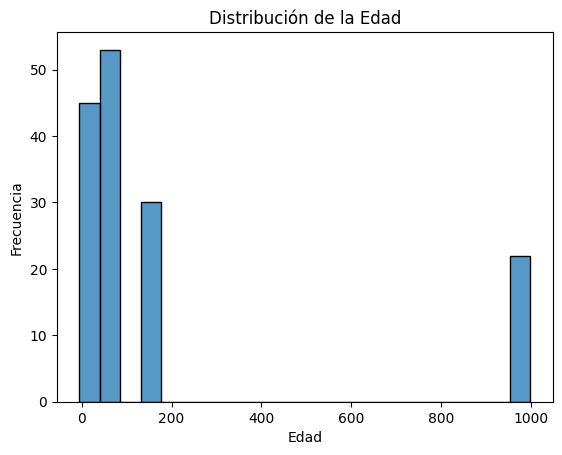

In [299]:
#sns.histplot(datos['Age'])
sns.histplot(data=datos, x='Age')
plt.title("Distribución de la Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

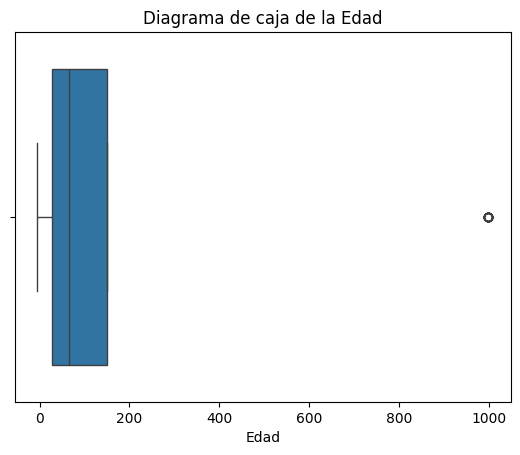

In [300]:
sns.boxplot(data=datos, x='Age')
plt.title("Diagrama de caja de la Edad")
plt.xlabel("Edad")
plt.show()

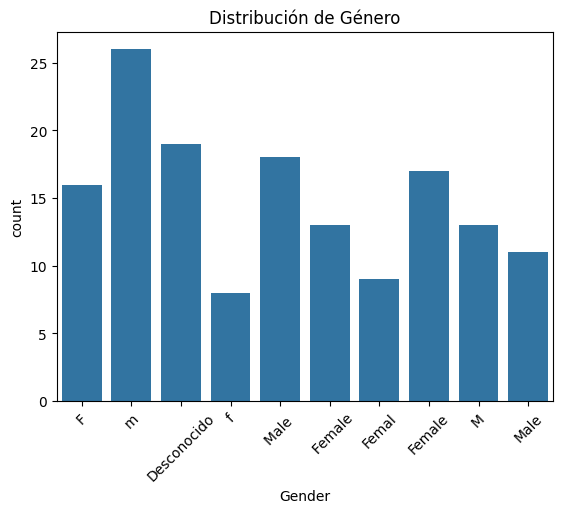

In [301]:
### Variable categorica de Genero

sns.countplot(data=datos, x='Gender')
plt.title("Distribución de Género")
plt.xticks(rotation=45)
plt.show()

In [302]:
datos['Gender'].value_counts()

Gender
m              26
Desconocido    19
Male           18
Female         17
F              16
  Female       13
M              13
Male           11
Femal           9
f               8
Name: count, dtype: int64

In [303]:
## Limpiar los caracteres en blanco del texto
datos['Gender Limpio'] = datos['Gender'].str.lower().str.strip()

## Estandardizar los diferentes valores de la variable genero
datos['Gender Limpio'] = datos['Gender Limpio'].str.replace("^m.*","M", regex=True)
datos['Gender Limpio'] = datos['Gender Limpio'].str.replace("^f.*","F", regex=True)

<Axes: xlabel='Gender Limpio', ylabel='count'>

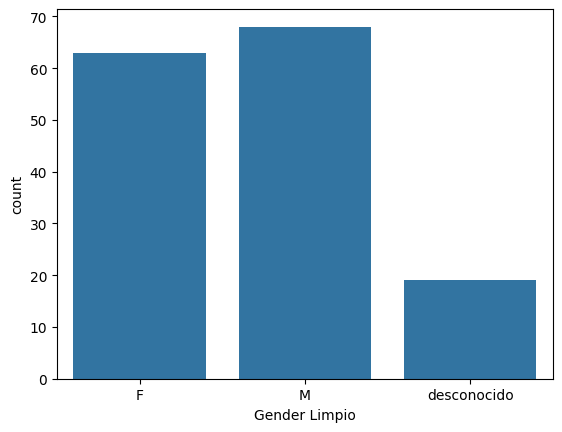

In [304]:
sns.countplot(data=datos, x='Gender Limpio')

<Axes: xlabel='Is_Subscribed', ylabel='count'>

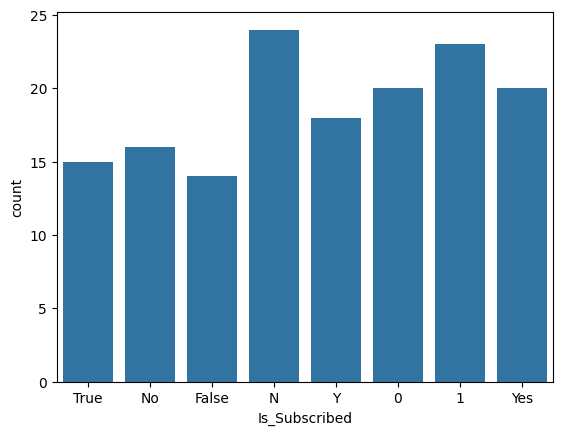

In [305]:
sns.countplot(data=datos, x='Is_Subscribed')

In [306]:
## Limpiar los caracteres en blanco del texto
datos['Is_Subscribed Limpio'] = datos['Is_Subscribed'].str.lower().str.strip()

## Estandardizar los diferentes valores de la variable genero
datos['Is_Subscribed Limpio'] = datos['Is_Subscribed Limpio'].str.replace("^t.*","1", regex=True)
datos['Is_Subscribed Limpio'] = datos['Is_Subscribed Limpio'].str.replace("^f.*","0", regex=True)
datos['Is_Subscribed Limpio'] = datos['Is_Subscribed Limpio'].str.replace("^n.*","0", regex=True)
datos['Is_Subscribed Limpio'] = datos['Is_Subscribed Limpio'].str.replace("^y.*","1", regex=True)

Text(0.5, 1.0, 'Diagrama de barras de Suscripción')

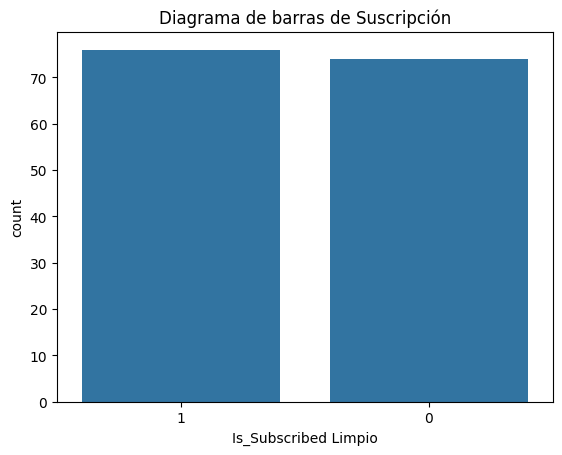

In [307]:
sns.countplot(data=datos, x='Is_Subscribed Limpio')
plt.title("Diagrama de barras de Suscripción")

Text(0.5, 1.0, 'Diagrama de dispersión de Edad vs Ingreso')

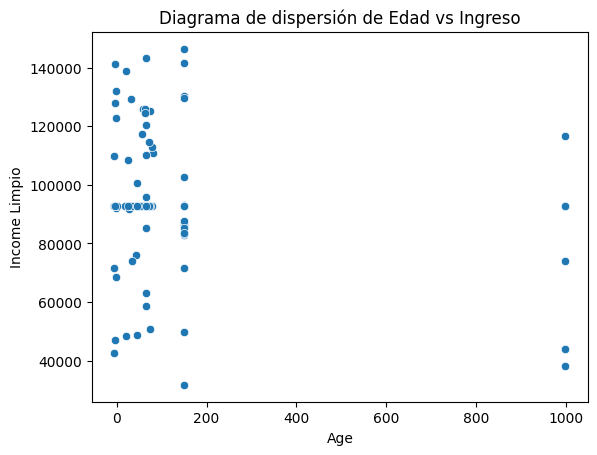

In [308]:
## Analisis multivariado
### Comparar las variables numericas para ver si tienen relacion entre ellas 

sns.scatterplot(data=datos, x='Age', y='Income Limpio')
plt.title("Diagrama de dispersión de Edad vs Ingreso")

Text(0.5, 1.0, 'Mapa de calor de correlación entre Edad e Ingreso')

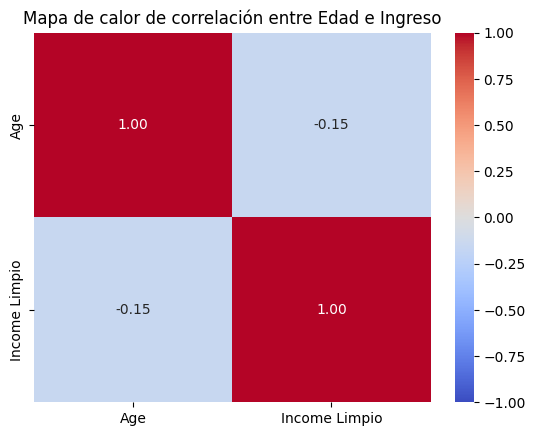

In [309]:
### Mapa de calor de correlacion entre las variables numericas
cm = datos[['Age', 'Income Limpio']].corr()
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Mapa de calor de correlación entre Edad e Ingreso")

In [310]:
datos

,Transaction_ID,Customer_Name,Age,Gender,Income,Join_Date,Purchase_Amount,Is_Subscribed,City,TipoTransaccion,NumeroTransaccion,Income Limpio,Join Date Limpio,Gender Limpio,Is_Subscribed Limpio
0,TRX-2824,Alice M.,999.0,F,NaN,09/09/2021,279.912294,True,los angeles,TRX,2824,92829.0,2021-09-09,F,1
1,TRX-1409,Alice M.,22.0,m,NaN,2021/06/07,158.384057,No,Desconocido,TRX,1409,92829.0,2021-06-07,M,0
2,TRX-5506,Frank_Wright,-4.0,Desconocido,127874,10/15/2022,256.260841,True,Chicago,TRX,5506,127874.0,2022-10-15,desconocido,1
3,TRX-5012,Grace!!,-4.0,f,NaN,02/17/2022,471.387424,False,Chicago,TRX,5012,92829.0,2022-02-17,F,0
4,TRX-4657,Alice M.,999.0,Male,Unknown,30/09/2023,332.779108,N,New York,TRX,4657,92829.0,2023-09-30,M,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,TRX-2290,Alice M.,150.0,Male,83379,2023/15/01,15.603510,False,Desconocido,TRX,2290,83379.0,NaT,M,0
146,TRX-2403,Charlie,66.0,Femal,Unknown,09/11/2020,349.456609,No,new york,TRX,2403,92829.0,2020-11-09,F,0
147,TRX-8962,Frank_Wright,150.0,f,NaN,27/11/2020,272.224616,N,Desconocido,TRX,8962,92829.0,2020-11-27,F,0
148,TRX-2133,david,46.0,Desconocido,92639,2023/15/01,160.335108,Yes,Desconocido,TRX,2133,92639.0,NaT,desconocido,1


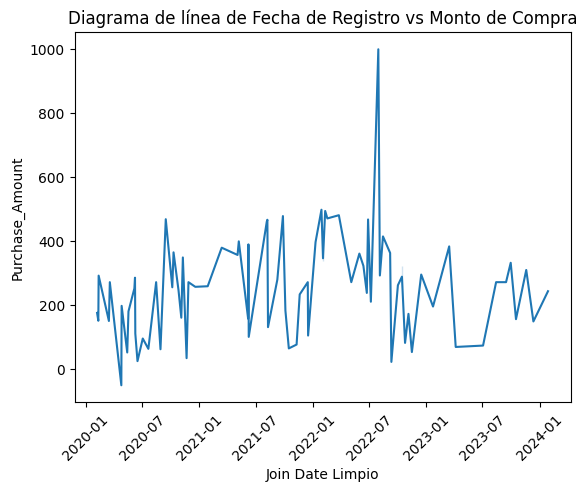

In [318]:
## Grafico de linea 

sns.lineplot(data=datos, x='Join Date Limpio', y='Purchase_Amount')
plt.title("Diagrama de línea de Fecha de Registro vs Monto de Compra")
plt.xticks(rotation=45)
plt.show()